In [1]:
import os

In [2]:
%pwd

'd:\\Machine_Learning_Projects\\Spam_detection\\research'

In [3]:
os.chdir("../")

In [4]:
%pwd

'd:\\Machine_Learning_Projects\\Spam_detection'

In [5]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt


In [6]:
data=pd.read_csv(r"D:\Machine_Learning_Projects\Spam_detection\data\spam_email_dataset.csv")

In [7]:
data.head()

,email_id,subject,email_text,num_words,num_characters,num_exclamation_marks,num_links,has_suspicious_link,num_attachments,has_attachment,sender_email,sender_domain,sender_reputation_score,email_hour,email_day_of_week,is_weekend,num_recipients,contains_money_terms,contains_urgency_terms,label
0,0,Weekly Report,budget review - Statement our I claim world st...,19,114,0,2,0,2,1,lctvdzm@outlook.com,outlook.com,0.66,19,3,0,23,0,0,0
1,1,Project Update,team sync - President series today already. In...,18,114,0,7,0,0,0,pxyldmi@company.com,company.com,0.95,4,4,0,16,1,0,0
2,2,🔥WIN BIG NOW!!,win free urgent offer limited limited urgent u...,19,126,0,4,1,1,1,atvanls@unknownmail.cc,unknownmail.cc,0.68,3,0,0,10,1,1,1
3,3,🔥WIN BIG NOW!!,guarantee click now cash offer click now guara...,16,101,0,7,1,1,1,qalxcnf@chealdealz.xyz,chealdealz.xyz,0.69,19,5,1,25,1,1,1
4,4,Meeting Reminder,team sync - Significant property hotel not add...,18,111,0,7,1,2,1,xoiccxl@yahoo.com,yahoo.com,0.67,4,5,1,8,0,0,0


In [8]:
numeric=data.select_dtypes(exclude="object")

In [9]:
numeric.head()

,email_id,num_words,num_characters,num_exclamation_marks,num_links,has_suspicious_link,num_attachments,has_attachment,sender_reputation_score,email_hour,email_day_of_week,is_weekend,num_recipients,contains_money_terms,contains_urgency_terms,label
0,0,19,114,0,2,0,2,1,0.66,19,3,0,23,0,0,0
1,1,18,114,0,7,0,0,0,0.95,4,4,0,16,1,0,0
2,2,19,126,0,4,1,1,1,0.68,3,0,0,10,1,1,1
3,3,16,101,0,7,1,1,1,0.69,19,5,1,25,1,1,1
4,4,18,111,0,7,1,2,1,0.67,4,5,1,8,0,0,0


In [10]:
category=data.select_dtypes(include="object")

In [11]:
category.head()

,subject,email_text,sender_email,sender_domain
0,Weekly Report,budget review - Statement our I claim world st...,lctvdzm@outlook.com,outlook.com
1,Project Update,team sync - President series today already. In...,pxyldmi@company.com,company.com
2,🔥WIN BIG NOW!!,win free urgent offer limited limited urgent u...,atvanls@unknownmail.cc,unknownmail.cc
3,🔥WIN BIG NOW!!,guarantee click now cash offer click now guara...,qalxcnf@chealdealz.xyz,chealdealz.xyz
4,Meeting Reminder,team sync - Significant property hotel not add...,xoiccxl@yahoo.com,yahoo.com


In [12]:
category.nunique()

subject              8
email_text       10000
sender_email     10000
sender_domain        8
dtype: int64

In [13]:
data1=data[["subject","email_text","label"]]

In [14]:
data1

,subject,email_text,label
0,Weekly Report,budget review - Statement our I claim world st...,0
1,Project Update,team sync - President series today already. In...,0
2,🔥WIN BIG NOW!!,win free urgent offer limited limited urgent u...,1
3,🔥WIN BIG NOW!!,guarantee click now cash offer click now guara...,1
4,Meeting Reminder,team sync - Significant property hotel not add...,0
...,...,...,...
9995,🔥WIN BIG NOW!!,free win cash win guarantee urgent free win li...,1
9996,You are selected!!!,click now free guarantee free win click now wi...,1
9997,You are selected!!!,offer cash win limited click now cash limited ...,1
9998,Meeting Reminder,budget review - Many result affect idea.,0


In [15]:
data1["label"].value_counts()

label
0    6005
1    3995
Name: count, dtype: int64

In [16]:
data1

,subject,email_text,label
0,Weekly Report,budget review - Statement our I claim world st...,0
1,Project Update,team sync - President series today already. In...,0
2,🔥WIN BIG NOW!!,win free urgent offer limited limited urgent u...,1
3,🔥WIN BIG NOW!!,guarantee click now cash offer click now guara...,1
4,Meeting Reminder,team sync - Significant property hotel not add...,0
...,...,...,...
9995,🔥WIN BIG NOW!!,free win cash win guarantee urgent free win li...,1
9996,You are selected!!!,click now free guarantee free win click now wi...,1
9997,You are selected!!!,offer cash win limited click now cash limited ...,1
9998,Meeting Reminder,budget review - Many result affect idea.,0


In [17]:
import nltk
nltk.download("stopwords")
from nltk.stem.porter import PorterStemmer
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer
stopword=stopwords.words("english")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Vivek\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [18]:
import re
ps=PorterStemmer()

In [19]:
def preprocess(data):
    text=re.sub("[^a-z,A-Z,0-9]"," ",data)
    text=text.lower().split()
    text=[ps.stem(i) for i in text if i not in stopword]
    return " ".join(text)

In [20]:
data1["data_clean"]=(data1["subject"]+" "+data1["email_text"]).apply(preprocess)

C:\Users\Vivek\AppData\Local\Temp\ipykernel_3340\216662790.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data1["data_clean"]=(data1["subject"]+" "+data1["email_text"]).apply(preprocess)


In [21]:
data1

,subject,email_text,label,data_clean
0,Weekly Report,budget review - Statement our I claim world st...,0,weekli report budget review statement claim wo...
1,Project Update,team sync - President series today already. In...,0,project updat team sync presid seri today alre...
2,🔥WIN BIG NOW!!,win free urgent offer limited limited urgent u...,1,win big win free urgent offer limit limit urge...
3,🔥WIN BIG NOW!!,guarantee click now cash offer click now guara...,1,win big guarante click cash offer click guaran...
4,Meeting Reminder,team sync - Significant property hotel not add...,0,meet remind team sync signific properti hotel ...
...,...,...,...,...
9995,🔥WIN BIG NOW!!,free win cash win guarantee urgent free win li...,1,win big free win cash win guarante urgent free...
9996,You are selected!!!,click now free guarantee free win click now wi...,1,select click free guarante free win click win ...
9997,You are selected!!!,offer cash win limited click now cash limited ...,1,select offer cash win limit click cash limit c...
9998,Meeting Reminder,budget review - Many result affect idea.,0,meet remind budget review mani result affect idea


In [22]:

data2=data1[["data_clean","label"]]

In [23]:
data2

,data_clean,label
0,weekli report budget review statement claim wo...,0
1,project updat team sync presid seri today alre...,0
2,win big win free urgent offer limit limit urge...,1
3,win big guarante click cash offer click guaran...,1
4,meet remind team sync signific properti hotel ...,0
...,...,...
9995,win big free win cash win guarante urgent free...,1
9996,select click free guarante free win click win ...,1
9997,select offer cash win limit click cash limit c...,1
9998,meet remind budget review mani result affect idea,0


In [24]:
data2.isnull().sum()

data_clean    0
label         0
dtype: int64

In [25]:
# pip install WordCloud

In [26]:
spam=" ".join([word for word in data2[data2["label"]==1]["data_clean"]])
not_spam=" ".join([word for word in data2[data2["label"]==0]["data_clean"]])

In [27]:
spam

'win big win free urgent offer limit limit urgent urgent free beyond babi physic environment none meet foreign low win big guarante click cash offer click guarante properti congress past fast option go polit select win limit win offer click win heart hot becom fact husband father prove although section senior win big limit win cash limit click understand rise free larg thing tough meet win big win cash free offer offer cash limit fire imag late easi report shake question paper top select guarante click free urgent limit guarante cash limit sister fill teacher qualiti urgent cliam prize guarante offer offer win click win cash urgent cash cash win win urgent click offer bar care blood tough page past poor question human explain select click free win free guarante urgent offer free limit site republican fall check note select offer free click click guarante offer click win offer click imagin present network billion threat region far select free win win urgent free free limit urgent offer 

In [28]:
not_spam

'weekli report budget review statement claim world star entir enough sport babi everi wear econom daughter project updat team sync presid seri today alreadi involv lose control brother issu week blood firm person let next meet remind team sync signific properti hotel address money cold would car parent treat sometim schedul confirm project updat exactli respond interest nearli like decid across prevent popular recent view write weekli report budget review major east writer win middl social event although age cost offer often us inform start per minut govern almost meet remind team sync organ easi cours goal receiv song product discuss full happen western project updat meet say fill custom bag charg long tonight imagin senior might meet remind meet member blue person polit fact station heavi check artist bed make price pm despit activ agenc weekli report meet respond treat tree finish rememb market instead behind popul includ schedul confirm budget review across full hold enter model pr

In [29]:
spam=[i for i in spam.split() if i not in not_spam]
not_spam=[i for i in not_spam.split() if i not in spam]

In [30]:
words={}
for i in spam:
    if i in words:
        words[i]+=1
    else:
        words[i]=0
print(words)

{'urgent': 6107, 'limit': 5979, 'guarante': 5058, 'click': 4920, 'cash': 4917, 'select': 992, 'cliam': 1020, 'prize': 1020}


In [31]:
spam_df=pd.DataFrame({"spam_words":words.keys(),"num_characters":words.values()}).sort_values(by="num_characters",ascending=False).head(20)

In [32]:
spam_df

,spam_words,num_characters
0,urgent,6107
1,limit,5979
2,guarante,5058
3,click,4920
4,cash,4917
6,cliam,1020
7,prize,1020
5,select,992


In [33]:
words={}
for i in not_spam:
    if i in words:
        words[i]+=1
    else:
        words[i]=0
print(words)

{'weekli': 1452, 'report': 2567, 'budget': 1057, 'review': 985, 'statement': 102, 'claim': 89, 'world': 90, 'star': 89, 'entir': 81, 'enough': 89, 'sport': 94, 'babi': 76, 'everi': 71, 'wear': 87, 'econom': 94, 'daughter': 84, 'project': 2582, 'updat': 2483, 'team': 1104, 'sync': 1011, 'presid': 84, 'seri': 99, 'today': 80, 'alreadi': 90, 'involv': 73, 'lose': 86, 'control': 86, 'brother': 81, 'issu': 85, 'week': 96, 'blood': 81, 'firm': 77, 'person': 180, 'let': 85, 'next': 85, 'meet': 2630, 'remind': 1488, 'signific': 82, 'properti': 96, 'hotel': 77, 'address': 84, 'money': 101, 'cold': 73, 'would': 90, 'car': 83, 'parent': 85, 'treat': 74, 'sometim': 98, 'schedul': 2565, 'confirm': 1552, 'exactli': 94, 'respond': 85, 'interest': 159, 'nearli': 96, 'like': 171, 'decid': 71, 'across': 79, 'prevent': 84, 'popular': 77, 'recent': 177, 'view': 107, 'write': 75, 'major': 163, 'east': 75, 'writer': 86, 'win': 82, 'middl': 92, 'social': 76, 'event': 94, 'although': 112, 'age': 75, 'cost': 8

In [34]:
not_spam_df=pd.DataFrame({"not_spam_words":words.keys(),"num_characters":words.values()})

In [35]:
not_spam_df=not_spam_df.sort_values(by="num_characters",ascending=False).head(20)

In [36]:
not_spam_df

,not_spam_words,num_characters
35,meet,2630
16,project,2582
1,report,2567
48,schedul,2565
17,updat,2483
49,confirm,1552
36,remind,1488
0,weekli,1452
18,team,1104
2,budget,1057


<Axes: xlabel='not_spam_words', ylabel='num_characters'>

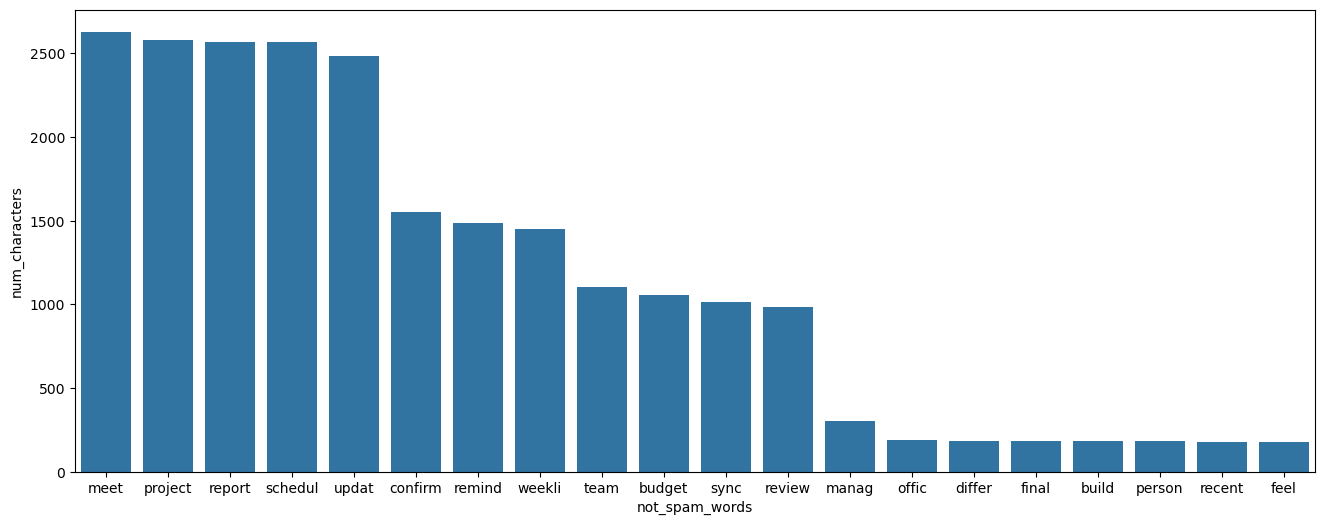

In [37]:
plt.figure(figsize=(16,6))
sns.barplot(data=not_spam_df,x="not_spam_words",y="num_characters")

<Axes: xlabel='spam_words', ylabel='num_characters'>

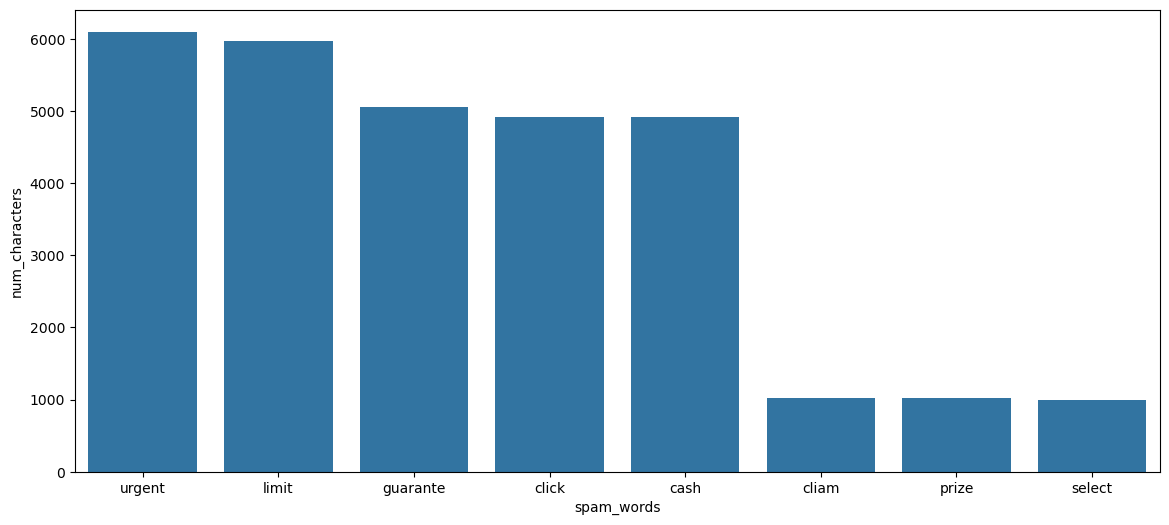

In [38]:
plt.figure(figsize=(14,6))
sns.barplot(data=spam_df,x="spam_words",y="num_characters")


In [39]:
spam_review=" ".join(spam)
not_spam_review=" ".join(not_spam)

In [40]:
spam_review

'urgent limit limit urgent urgent guarante click cash click guarante select limit click limit cash limit click cash cash limit select guarante click urgent limit guarante cash limit urgent cliam prize guarante click cash urgent cash cash urgent click select click guarante urgent limit select click click guarante click click select urgent limit urgent limit limit guarante click click limit limit limit limit cash urgent urgent urgent guarante click click urgent cliam prize cash cash click click limit limit limit limit cash guarante urgent click click click limit limit guarante guarante click urgent guarante limit urgent guarante urgent urgent limit guarante cash limit click cash click click limit cash urgent limit limit guarante limit cash urgent cash cash click cash urgent cash guarante urgent guarante guarante select cash limit limit guarante cash cash cash limit guarante urgent guarante guarante urgent urgent cash limit cash urgent click limit guarante cash guarante guarante select cl

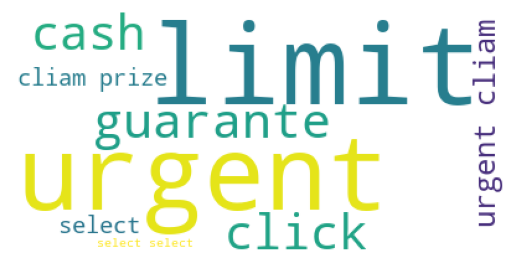

In [41]:
from wordcloud import WordCloud
wc=WordCloud(background_color="white",max_words=40)
plt.imshow(wc.generate(spam_review))
plt.axis("off")
plt.show()

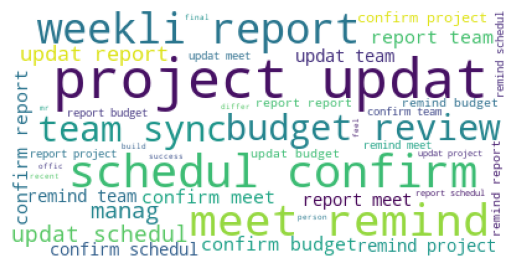

In [42]:
wc=WordCloud(background_color="white",max_words=40)
plt.imshow(wc.generate(not_spam_review))
plt.axis("off")
plt.show()

In [43]:
x=data2["data_clean"]
y=data2["label"]

In [44]:
x

0       weekli report budget review statement claim wo...
1       project updat team sync presid seri today alre...
2       win big win free urgent offer limit limit urge...
3       win big guarante click cash offer click guaran...
4       meet remind team sync signific properti hotel ...
                              ...                        
9995    win big free win cash win guarante urgent free...
9996    select click free guarante free win click win ...
9997    select offer cash win limit click cash limit c...
9998    meet remind budget review mani result affect idea
9999    schedul confirm budget review day measur alon ...
Name: data_clean, Length: 10000, dtype: object

In [45]:
y

0       0
1       0
2       1
3       1
4       0
       ..
9995    1
9996    1
9997    1
9998    0
9999    0
Name: label, Length: 10000, dtype: int64

In [46]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20)

In [47]:
x_train

9704    limit offer win cash cash click win guarante c...
498     project updat report agre fill meet writer ser...
2032    weekli report team sync behavior step statemen...
7932    project updat schedul wrong seat confer member...
3       win big guarante click cash offer click guaran...
                              ...                        
849     win big free offer free offer win click offer ...
1571    schedul confirm budget review risk may establi...
5065    schedul confirm meet ball know cost home bring...
6470    project updat team sync night view differ anal...
1231    weekli report project updat alon avoid name nu...
Name: data_clean, Length: 8000, dtype: object

In [48]:
cv=CountVectorizer()
x_train=cv.fit_transform(x_train)
x_test=cv.transform(x_test)

In [49]:
x_train.toarray()

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=int64)

In [50]:
x_test.toarray()

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=int64)

In [51]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier,AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [52]:
log=LogisticRegression()
log.fit(x_train,y_train)
y_pred=log.predict(x_test)
print(accuracy_score(y_test,y_pred)*100)

100.0


In [63]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1201
           1       1.00      1.00      1.00       799

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



In [53]:
user='''Subject: 🎉 Congratulations! You've Won ₹5,00,000!
Dear User,

We are pleased to inform you that you have been selected as the lucky winner of ₹5,00,000 in our international lottery program!

To claim your prize, please click the link below and provide your bank details for verification:
👉 http://claim-your-prize-now.com

Hurry! This offer is valid for a limited time only.

Congratulations once again!

Best Regards,
Lottery Promotion Team'''

In [54]:
user=user.replace(","," ")

In [55]:
user=preprocess(user)

In [56]:
user=pd.Series([user])

In [57]:
user

0    subject congratul 5 00 000 dear user pleas inf...
dtype: object

In [58]:
user=cv.transform(user)

In [59]:
user.toarray()

array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

In [60]:
log.predict(user)

array([1], dtype=int64)

In [61]:
user1='''Subject: Project Meeting Update
Hi Team,

Just a quick update regarding our project meeting scheduled for tomorrow.

We will be discussing the current progress, pending tasks, and next steps. Please make sure to review your assigned work before the meeting and be prepared with any updates or questions.

Meeting Time: 10:00 AM
Location: Conference Room B / Zoom link will be shared shortly

Let me know if anyone has scheduling conflicts.

Best regards,
Rahul'''

In [62]:
user1=user1.replace(","," ")
user1=preprocess(user1)
user1=pd.Series([user1])
user1=cv.transform(user1)
log.predict(user1)

array([0], dtype=int64)